In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_score

# SHAP para Explicabilidade
import shap

Carregando Tabela Analítica...
Executando GridSearchCV com Validação Cruzada (Foco em Precisão)...

Melhores Hiperparâmetros Encontrados: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}

--- Relatório de Classificação (Threshold Padrão 0.5) ---
              precision    recall  f1-score   support

           0       0.64      0.90      0.75      4333
           1       0.50      0.16      0.24      2617

    accuracy                           0.62      6950
   macro avg       0.57      0.53      0.50      6950
weighted avg       0.59      0.62      0.56      6950


--- Relatório com Limiar de Confiança Ajustado (0.55) ---
              precision    recall  f1-score   support

           0       0.64      0.93      0.76      4333
           1       0.52      0.13      0.21      2617

    accuracy                           0.63      6950
   macro avg       0.58      0.53      0.48      6950
weighted avg       0.59      0.63      0.55  

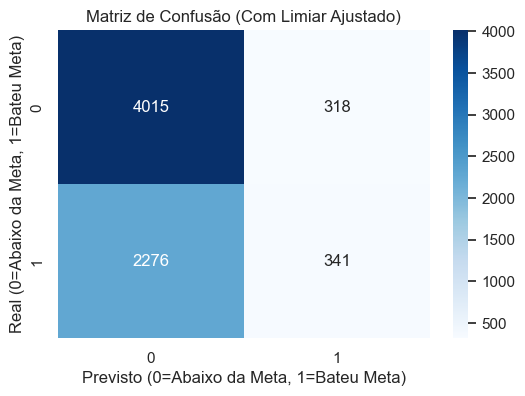


Calculando valores SHAP para interpretabilidade dos Stakeholders...


C:\Users\gugag\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\gugag\AppData\Local\Temp\ipykernel_10340\3640557770.py:163: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


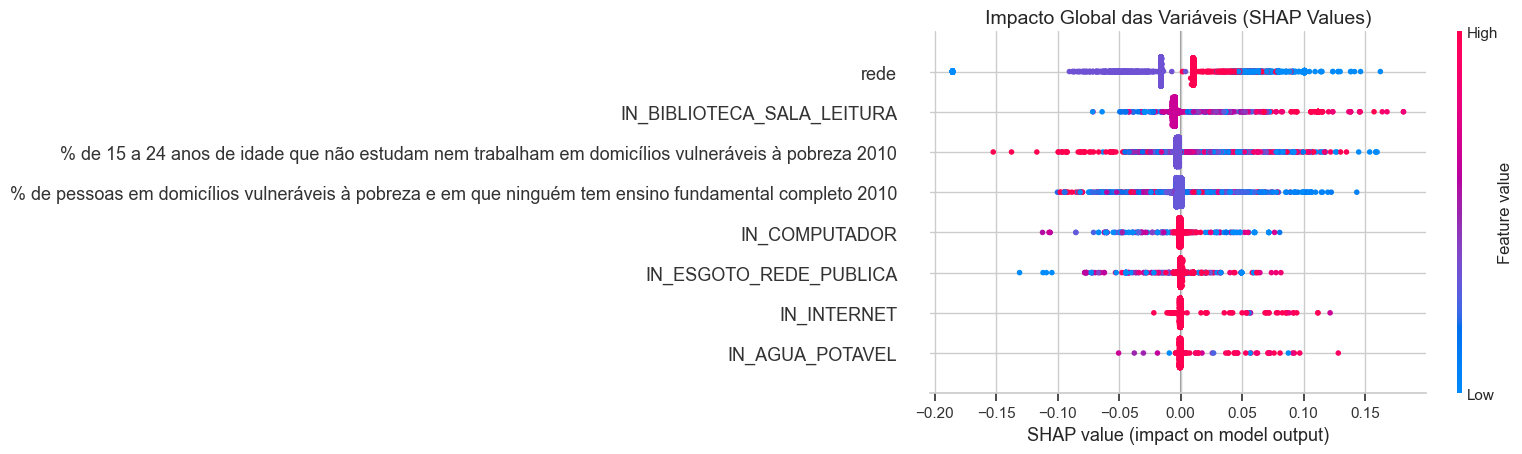

In [6]:
# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ====================================================================
# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS (SEM DATA LEAKAGE)
# ====================================================================
print("Carregando Tabela Analítica...")
df_master = pd.read_parquet("abt_alfabetizacao_modelagem.parquet")

# Criando a variável alvo binária (1 = Bateu ou Superou a Meta, 0 = Abaixo da Meta)
df_master['alvo'] = df_master['status_meta'].apply(lambda x: 1 if x in ['Acima da Meta', 'Atingiu a Meta'] else 0)

# A GRANDE FAXINA: Removendo o gabarito, os cálculos do gabarito e as metas futuras
cols_to_drop = [
    # Identificadores e Target
    'id_municipio', 'ano', 'status_meta', 'alvo', 'serie',
    
    # Variáveis de Performance (O Gabarito)
    'taxa_alfabetizacao', 'nivel_alfabetizacao', 'media_portugues', 'delta_meta_2024',
    
    # Proporções de alunos (Fatias do Gabarito)
    'proporcao_aluno_nivel_0', 'proporcao_aluno_nivel_1', 'proporcao_aluno_nivel_2',
    'proporcao_aluno_nivel_3', 'proporcao_aluno_nivel_4', 'proporcao_aluno_nivel_5',
    'proporcao_aluno_nivel_6', 'proporcao_aluno_nivel_7', 'proporcao_aluno_nivel_8',
    'percentual_participacao',
    
    # Metas futuras (Não têm valor preditivo para o momento atual)
    'meta_alfabetizacao_2024', 'meta_alfabetizacao_2025', 'meta_alfabetizacao_2026', 
    'meta_alfabetizacao_2027', 'meta_alfabetizacao_2028', 'meta_alfabetizacao_2029', 
    'meta_alfabetizacao_2030'
]

X = df_master.drop(columns=cols_to_drop, errors='ignore')
y = df_master['alvo']

# Divisão de Treino e Teste com Estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# ====================================================================
# 2. CONSTRUÇÃO DO PIPELINE DE PRÉ-PROCESSAMENTO
# ====================================================================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


# ====================================================================
# 3. OTIMIZAÇÃO DE HIPERPARÂMETROS COM GRID SEARCH E CROSS-VALIDATION
# ====================================================================
# Adicionando o class_weight='balanced'
pipeline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Grade de parâmetros para evitar Overfitting/Underfitting
# Limitamos a profundidade máxima (max_depth) e exigimos amostras mínimas por folha
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [6, 10, 15],
    'classifier__min_samples_split': [5, 10]
}

# Estratégia de validação cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# REGRA DE NEGÓCIO: Otimizamos para 'precision' (Precisão). 
# Isso pune severamente os Falsos Positivos (municípios previstos como "batendo a meta", mas que falham).
print("Executando GridSearchCV com Validação Cruzada (Foco em Precisão)...")
grid_search = GridSearchCV(
    estimator=pipeline_clf,
    param_grid=param_grid,
    scoring='precision', 
    cv=cv_strategy,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nMelhores Hiperparâmetros Encontrados: {grid_search.best_params_}")
best_model = grid_search.best_estimator_


# ====================================================================
# 4. AVALIAÇÃO DE DESEMPENHO E TRATAMENTO DE FALSOS POSITIVOS
# ====================================================================
# Previsão padrão com limiar de 50% de probabilidade
y_pred = best_model.predict(X_test)

print("\n--- Relatório de Classificação (Threshold Padrão 0.5) ---")
print(classification_report(y_test, y_pred))

# Ajuste Opcional de Limiar (Threshold Tuning) para zerar Falsos Positivos críticos:
# Em vez de 0.5, exigimos maior confiança do modelo (ex: 0.7 de probabilidade para prever 1)
y_proba = best_model.predict_proba(X_test)[:, 1]
custom_threshold = 0.55
y_pred_custom = (y_proba >= custom_threshold).astype(int)

print(f"\n--- Relatório com Limiar de Confiança Ajustado ({custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))

# Matriz de Confusão
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_custom), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão (Com Limiar Ajustado)")
plt.xlabel("Previsto (0=Abaixo da Meta, 1=Bateu Meta)")
plt.ylabel("Real (0=Abaixo da Meta, 1=Bateu Meta)")
plt.show()


# ====================================================================
# 5. EXPLICABILIDADE COM SHAP (JUSTIFICANDO AS PREVISÕES)
# ====================================================================
print("\nCalculando valores SHAP para interpretabilidade dos Stakeholders...")

# Extraindo o pré-processador e o classificador treinado do melhor modelo
preprocessor_fitted = best_model.named_steps['preprocessor']
rf_model_fitted = best_model.named_steps['classifier']

# Transformando os dados de teste para o formato que a árvore entende
X_test_transformed = preprocessor_fitted.transform(X_test)

# Extraindo os nomes reais das colunas direto do pré-processador (Método moderno e à prova de falhas)
all_feature_names = preprocessor_fitted.get_feature_names_out()
# Limpando os prefixos chatos que o Scikit-learn coloca (ex: 'num__IN_INTERNET' vira 'IN_INTERNET')
all_feature_names = [nome.split('__')[-1] for nome in all_feature_names]

# Gerando o Explainer do SHAP para árvores
explainer = shap.TreeExplainer(rf_model_fitted)

# O SHAP retorna uma lista para classificação binária. O índice [1] representa a probabilidade de "Bater a Meta"
shap_values = explainer.shap_values(X_test_transformed)

# Para a versão mais recente do SHAP, às vezes o formato muda um pouco.
# Se shap_values for uma lista (modelo Random Forest clássico), pegamos [1]
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
else:
    # Se for um array 3D, fatiamos para a classe positiva
    shap_vals_to_plot = shap_values[:, :, 1] if len(shap_values.shape) > 2 else shap_values

# Gráfico de Resumo (Summary Plot)
plt.figure()
shap.summary_plot(shap_vals_to_plot, X_test_transformed, feature_names=all_feature_names, show=False)
plt.title("Impacto Global das Variáveis (SHAP Values)", fontsize=14)
plt.tight_layout()
plt.show()